### Job Descriptions (JDs) — Ingestion & Cleaning (Adzuna)

This notebook builds a clean, de-duplicated JD corpus that we can 
(i) use for the app, 
(ii) mine phrases from, and 
(iii) sample for our small labelled evaluation set.

**This notebook does**

- Pull JDs from the Adzuna API for a roles × locations plan

- Cache raw JSON responses (reproducible + offline)

- Flatten & clean text (HTML → plain text, unicode/whitespace normalize)

- Deduplicate by (title + company + location) (plus description hash)

- Apply quality filters (min tokens/chars)

- Save tidy outputs and a small data-quality report

- Produce a few quick EDA plots for the report

**Outputs**

data/raw/adzuna/*.json — raw API dumps

data/processed/jds_clean.parquet (and .csv) — canonical clean JDs

data/raw/jds.csv — small CSV for quick downstream use

reports/jd_quality.json — counts, lengths, duplicates removed

figures/jd_tokens_hist.png, figures/jds_by_domain.png — EDA

In [2]:
pip install python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os, re, json, time, math, unicodedata, hashlib, random
from pathlib import Path
from typing import List, Dict, Any, Iterable
from dotenv import load_dotenv, find_dotenv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import requests
    _REQ_OK = True
except Exception:
    _REQ_OK = False

try:
    from unidecode import unidecode
except Exception:
    def unidecode(x: str) -> str: return x  # fallback

try:
    from rapidfuzz import fuzz
    _FUZZ_OK = True
except Exception:
    _FUZZ_OK = False

# Reproducibility
RANDOM_SEED = 42
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Project Folders
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT/"data"
RAW_DIR = DATA_DIR/"raw"
PROCESSED_DIR = DATA_DIR/"processed"
MODELS_DIR = PROJECT_ROOT/"models"
FIGURES_DIR = PROJECT_ROOT/"figures"
ARTIFACTS_DIR = PROJECT_ROOT/"artifacts"
LOGS_DIR = PROJECT_ROOT/"logs"
REPORTS_DIR = PROJECT_ROOT/"reports"

for d in [DATA_DIR, RAW_DIR, PROCESSED_DIR, MODELS_DIR, FIGURES_DIR, ARTIFACTS_DIR, LOGS_DIR, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

#### Roles × locations plan

We pull JDs using a small plan that combines domain, role keywords, and locations. You can define this inline or via roles_config.csv.

Expected columns in roles_config.csv:

- **domain** — broad category (e.g., Software/IT, Data/AI, Marketing, Finance…)

- **what** — search query (e.g., “data scientist”, “software engineer python”)

- **locations** — comma-separated cities/regions (e.g., “London,Manchester,Birmingham”)

- **pages** — how many pages to fetch per (what, location)

This keeps the JD set diverse and avoids overfitting to one role.

In [34]:
# Files
PLAN_CSV = RAW_DIR / "roles_config.csv"
RAW_JD_CSV = RAW_DIR/ "jds.csv"
CLEAN_PARQUET = PROCESSED_DIR/ "jd_clean.parquet"
CLEAN_CSV = PROCESSED_DIR/ "jd_clean.csv"
QUALITY_JSON = REPORTS_DIR/ "jd_quality.json"

# Config
ONLINE = True
COUNTRY = "gb"
ADZUNA_BASE_URL = os.getenv("ADZUNA_BASE_URL", "https://api.adzuna.com/v1/api/jobs")
APP_ID = os.getenv("ADZUNA_APP_ID", "")
APP_KEY = os.getenv("ADZUNA_APP_KEY", "")

USE_PLAN = PLAN_CSV.exists()
ROLES = [
    "Software Engineer Python",
    "Data Analyst SQL",
    "DevOps Engineer Kubernetes",
    "Machine Learning Engineer NLP",
    "Frontend Engineer React",
    "Accountant",
    "Registered Nurse",
    "Project Manager",
]
LOCATIONS = ["London", "Manchester", "Birmingham"]
RESULTS_PER_PAGE = 50
MAX_PAGES_PER_QUERY = 3
SLEEP_SECS = 1.0

# Cleaning Config
MIN_CHARS = 100
MIN_TOKENS = 20
REDACT_EMAIL = True
REDACT_PHONE = True
REDACT_URL   = True
DUP_SIMILARITY = 92   # near-duplicate threshold for optional fuzzy dedup

#### Keys, terms of use, and rate limits

We access Adzuna with:

- ADZUNA_APP_ID

- ADZUNA_APP_KEY

Store them as environment variables in a .env file

Keep results_per_page reasonable (50)

Add a tiny sleep between requests

Cache all responses to disk; re-runs should reuse the cache

In [37]:
# load .env from the project root (or parent)
load_dotenv(find_dotenv())

APP_ID  = os.getenv("ADZUNA_APP_ID", "")
APP_KEY = os.getenv("ADZUNA_APP_KEY", "")

# quick sanity check (mask output)
print("Keys loaded:",
      bool(APP_ID), bool(APP_KEY),
      "| APP_ID preview:", (APP_ID[:4] + "…" if APP_ID else "MISSING"))
if not (APP_ID and APP_KEY):
    raise RuntimeError("Missing ADZUNA_APP_ID/ADZUNA_APP_KEY. Check your .env file.")

Keys loaded: True True | APP_ID preview: 309a…


#### Cleaning Helpers and JSON helpers

In [40]:
EMAIL_RE = re.compile(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b')
PHONE_RE = re.compile(r'(?:(?:\+?\d{1,3}[\s\-\.]?)?(?:\(?\d{3}\)?[\s\-\.]?)?\d{3}[\s\-\.]?\d{4})')
URL_RE   = re.compile(r'(https?://\S+|www\.\S+)')

def normalize_unicode(s: str) -> str:
    return unidecode(unicodedata.normalize("NFKC", s or ""))

def normalize_whitespace(s: str) -> str:
    s = (s or "").replace("\t", " ")
    s = s.replace("•", "- ").replace("·", "- ").replace("◦", "- ")
    s = re.sub(r"[ \u00A0]+", " ", s)
    s = re.sub(r"\n{3,}", "\n\n", s)
    return s.strip()

def strip_boilerplate(s: str) -> str:
    s = re.sub(r'\bpage\s*\d+\b', '', s, flags=re.I)
    s = re.sub(r'\bcontinued\b', '', s, flags=re.I)
    return s

def redact_basic(s: str) -> str:
    if REDACT_EMAIL: s = EMAIL_RE.sub("[EMAIL]", s)
    if REDACT_PHONE: s = PHONE_RE.sub("[PHONE]", s)
    if REDACT_URL:   s = URL_RE.sub("[URL]", s)
    return s

def basic_clean(s: str) -> str:
    s = normalize_unicode(s)
    s = strip_boilerplate(s)
    s = normalize_whitespace(s)
    s = redact_basic(s)
    return s

def token_count(s: str) -> int:
    return len((s or "").split())

In [42]:
plan = None
if PLAN_CSV.exists():
    plan = pd.read_csv(PLAN_CSV)
    assert {"domain", "what", "locations", "pages"}.issubset(plan.columns), "roles_config.csv missing required columns"
    print(f"Loaded plan rows: {len(plan)}")
else:
    print("roles_config.csv not found; falling back to ROLES/LOCATIONS lists.")

Loaded plan rows: 40


In [44]:
def write_jsonl(path: Path, rows: Iterable[Dict[str, Any]]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("a", encoding="utf-8") as f:
        for r in rows:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")

def read_jsonl(path: Path) -> List[Dict[str, Any]]:
    if not path.exists():
        return []
    out = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                out.append(json.loads(line))
            except Exception:
                pass
    return out

#### Raw fetch & caching (what happens)

For each (what, location) pair and page:

1. Call Adzuna search endpoint

2. Save the verbatim JSON to data/raw/adzuna/ with a predictable filename

3. If a file already exists, skip the network call (use cache)

This matters because of reproducibility, easy audits, and offline work.

In [47]:
def adzuna_search(role: str, location: str, *, page: int) -> Dict[str, Any]:
    if not _REQ_OK:
        raise ImportError("requests not installed; install it to fetch from Adzuna.")
    url = f"{ADZUNA_BASE_URL}/{COUNTRY}/search/{page}"
    params = {
    "app_id": APP_ID, "app_key": APP_KEY, "what": role, "where": location,
    "results_per_page": RESULTS_PER_PAGE, "content-type": "application/json"
    }
    r = requests.get(url, params=params, timeout=20)
    r.raise_for_status()
    return r.json()


def pull_adzuna_snapshot(roles: List[str], locations: List[str]) -> List[Path]:
    assert APP_ID and APP_KEY, "Missing ADZUNA_APP_ID / ADZUNA_APP_KEY env vars."
    caches = []
    for role in roles:
        for loc in locations:
            slug = re.sub(r"[^a-z0-9]+", "-", f"{role}-{loc}".lower()).strip("-")
            cache_path = RAW_DIR/ f"adzuna_{slug}.jsonl"
            print(f"[Fetch] {role} @ {loc} -> {cache_path}")
            for page in range(1, MAX_PAGES_PER_QUERY + 1):
                try:
                    js = adzuna_search(role, loc, page=page)
                    results = js.get("results") or js.get("jobs") or []
                    for rec in results:
                        rec["_domain"] = ""
                        rec["_query"] = role
                        rec["_location"] = loc
                    write_jsonl(cache_path, results)
                    time.sleep(SLEEP_SECS)
                except Exception as e:
                    print(" ! error on page", page, "->", e)
                    break
            caches.append(cache_path)
    return caches


def pull_adzuna_from_plan(plan_df: pd.DataFrame) -> List[Path]:
    assert APP_ID and APP_KEY, "Missing ADZUNA_APP_ID / ADZUNA_APP_KEY env vars."
    caches = []
    for _, r in plan_df.iterrows():
        domain = str(r["domain"])
        role = str(r["what"])
        pages = int(r.get("pages", 1))
        for loc in str(r["locations"]).split("|"):
            loc = loc.strip()
            slug = re.sub(r"[^a-z0-9]+", "-", f"{domain}-{role}-{loc}".lower()).strip("-")
            cache_path = RAW_DIR / f"adzuna_{slug}.jsonl"
            print(f"[Fetch] {domain} | {role} @ {loc} -> {cache_path}")
            for page in range(1, pages + 1):
                try:
                    js = adzuna_search(role, loc, page=page)
                    results = js.get("results") or js.get("jobs") or []
                    for rec in results:
                        rec["_domain"] = domain
                        rec["_query"] = role
                        rec["_location"] = loc
                    write_jsonl(cache_path, results)
                    time.sleep(SLEEP_SECS)
                except Exception as e:
                    print(" ! error on page", page, "->", e)
                    break
            caches.append(cache_path)
    return caches

#### Normalize Adzuna job record

Convert a raw Adzuna JSON item into a flat, consistent dict for our JD table.

**Handles:** Variant keys and nested objects (e.g., company.display_name, location.display_name), falls back to "" if missing, and keeps provenance fields.

**Outputs (keys):**

1. domain – source domain/tag we assigned (from _domain)

2. query_used – the role text we searched (from _query)

3. query_location – the location we searched (from _location)

4. job_title – from title/job_title

5. company – from company.display_name or company

6. location – from location.display_name or location.area

7. jd_text_raw – raw HTML/text description (description/body/content)

8. created – posting timestamp (created/created_at)

9. source_url – redirect_url/url

10. category – category.label or category

In [50]:
def extract_from_record(rec: Dict[str, Any]) -> Dict[str, Any]:
    title = rec.get("title") or rec.get("job_title") or ""
    company = (rec.get("company") or {}).get("display_name") if isinstance(rec.get("company"), dict) else rec.get("company")
    if company is None:
        company = ""
    loc = rec.get("location", {})
    if isinstance(loc, dict):
        location = loc.get("display_name") or loc.get("area") or ""
    else:
        location = str(loc or "")
    desc = rec.get("description") or rec.get("body") or rec.get("content") or ""
    created = rec.get("created") or rec.get("created_at") or ""
    url = rec.get("redirect_url") or rec.get("url") or ""
    category = (rec.get("category") or {}).get("label") if isinstance(rec.get("category"), dict) else rec.get("category")
    if category is None: category = ""
    domain = rec.get("_domain", "")
    query_used = rec.get("_query", "")
    loc_used = rec.get("_location", "")
    return {
    "domain": str(domain),
    "query_used": str(query_used),
    "query_location": str(loc_used),
    "job_title": str(title),
    "company": str(company),
    "location": str(location),
    "jd_text_raw": str(desc),
    "created": str(created),
    "source_url": str(url),
    "category": str(category)
    }

#### Ingestion glue — using cache first, CSV as fallback

- **load_cached_to_df():**
Scans RAW_DIR for files named adzuna_*.jsonl, reads each page with read_jsonl(), normalizes every record via extract_from_record(...), and returns a single DataFrame of raw JDs.

- **fallback_from_manual_csv():**
If data/raw/jds.csv exists, maps its columns into the same schema (job_title, company, location, jd_text_raw, …) so downstream code can run even without the API cache.

**Main ingest switch**

If ONLINE is True:

Uses plan (pull_adzuna_from_plan(plan)) or the inline ROLES × LOCATIONS (pull_adzuna_snapshot) to fetch & cache JSONL pages.

Then calls load_cached_to_df() to build raw_df.

If no cache is found, falls back to fallback_from_manual_csv().

**Output**

Prints the number of raw JD rows and shows a preview.
This DataFrame is the input for the cleaning & dedup stage (HTML -> text, filters, hashing).

In [53]:
def load_cached_to_df() -> pd.DataFrame:
    rows = []
    for p in RAW_DIR.glob("adzuna_*.jsonl"):
        for rec in read_jsonl(p):
            rows.append(extract_from_record(rec))
    return pd.DataFrame(rows)

def fallback_from_manual_csv() -> pd.DataFrame:
    if RAW_JD_CSV.exists():
        df = pd.read_csv(RAW_JD_CSV)
        if "jd_text" in df.columns:
            out = pd.DataFrame({
                "domain": "",
                "query_used": df.get("query_used", pd.Series([""]*len(df))).astype(str),
                "query_location": df.get("location", pd.Series([""]*len(df))).astype(str),
                "job_title": df.get("job_title", pd.Series([""]*len(df))).astype(str),
                "company": df.get("company", pd.Series([""]*len(df))).astype(str),
                "location": df.get("location", pd.Series([""]*len(df))).astype(str),
                "jd_text_raw": df["jd_text"].astype(str),
                "created": df.get("date_collected", pd.Series([""]*len(df))).astype(str),
                "source_url": df.get("source_url", pd.Series([""]*len(df))).astype(str),
                "category": df.get("category", pd.Series([""]*len(df))).astype(str),
            })
            return out
    return pd.DataFrame(columns=["domain","query_used","query_location","job_title",
                                 "company","location","jd_text_raw","created","source_url",
                                 "category"])
# Main ingest switch
if ONLINE:
    if plan is not None:
        files = pull_adzuna_from_plan(plan)
    else:
        files = pull_adzuna_snapshot(ROLES, LOCATIONS)
    print("Cached files:", files)

raw_df = load_cached_to_df()
if raw_df.empty:
    print("No Adzuna cache found; falling back to manual CSV at data/raw/jds.csv")
    raw_df = fallback_from_manual_csv()

print("Raw JD rows:", len(raw_df))
display(raw_df.head())

[Fetch] Software/IT | Software Engineer Python @ London -> C:\Users\Keya Barua\Documents\MSC Data Science - Middlesex University\CST 4090\data\raw\adzuna_software-it-software-engineer-python-london.jsonl
[Fetch] Software/IT | Software Engineer Python @ Manchester -> C:\Users\Keya Barua\Documents\MSC Data Science - Middlesex University\CST 4090\data\raw\adzuna_software-it-software-engineer-python-manchester.jsonl
[Fetch] Software/IT | Software Engineer Python @ Birmingham -> C:\Users\Keya Barua\Documents\MSC Data Science - Middlesex University\CST 4090\data\raw\adzuna_software-it-software-engineer-python-birmingham.jsonl
[Fetch] Software/IT | Frontend Engineer React @ London -> C:\Users\Keya Barua\Documents\MSC Data Science - Middlesex University\CST 4090\data\raw\adzuna_software-it-frontend-engineer-react-london.jsonl
[Fetch] Software/IT | Frontend Engineer React @ Manchester -> C:\Users\Keya Barua\Documents\MSC Data Science - Middlesex University\CST 4090\data\raw\adzuna_software-it-f

,domain,query_used,query_location,job_title,company,location,jd_text_raw,created,source_url,category
0,,Accountant,Birmingham,Semi-Senior Accountant - Audit and Accounts,HAYS,"Birmingham, West Midlands",Semi-Senior Audit and Accounts role within an ...,2025-09-03T01:09:59Z,https://www.adzuna.co.uk/jobs/land/ad/53805492...,Accounting & Finance Jobs
1,,Accountant,Birmingham,Senior Accountant,HAYS,"Birmingham, West Midlands",Senior Accountant role in Birmingham offering ...,2025-07-09T15:16:56Z,https://www.adzuna.co.uk/jobs/land/ad/52936850...,Accounting & Finance Jobs
2,,Accountant,Birmingham,Assistant Accountant,HAYS,"Birmingham, West Midlands","Assistant Accountant, Birmingham, Hybrid-Worki...",2025-07-16T04:34:08Z,https://www.adzuna.co.uk/jobs/land/ad/53056536...,Accounting & Finance Jobs
3,,Accountant,Birmingham,Financial & Statutory Accountant,HAYS,"Birmingham, West Midlands","Financial Accountant, Statutory Accountant, UK...",2025-08-06T22:02:54Z,https://www.adzuna.co.uk/jobs/land/ad/53407102...,Accounting & Finance Jobs
4,,Accountant,Birmingham,Accounts Senior,HAYS,"Birmingham, West Midlands",Senior Accountant role - commercial focus work...,2025-08-22T01:28:21Z,https://www.adzuna.co.uk/jobs/land/ad/53630146...,Accounting & Finance Jobs


#### Cleaning, filtering & dedup

- **norm_for_hash(s)** – Lowercases, strips punctuation/underscores and collapses spaces

- **Build clean text & length features**

- **Quality filter**

Keep rows with n_chars ≥ MIN_CHARS and n_tokens ≥ MIN_TOKENS.

Prints how many short rows were removed.

- **Exact dedup**

hash_norm = md5(norm_for_hash(jd_text))

Drop duplicate hash_norm values; prints number of duplicate groups.

- **Soft near-duplicate (optional)**

If RapidFuzz is available (_FUZZ_OK), take up to 1,000 samples and compute fuzz.token_set_ratio.

Remove rows whose similarity ≥ DUP_SIMILARITY (e.g., 92).

Prints approximate count removed.

- **Finalize & save**

Drop helper columns (hash_norm, jd_text_raw).

Save clean JDs to a CSV file.

Parquet (best-effort) -> CLEAN_PARQUET

Logs what was written.

In [55]:
def norm_for_hash(s: str)-> str:
    s = (s or "").lower()
    s = re.sub(r'[\W_]+', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

df = raw_df.copy()
df["jd_text"] = df["jd_text_raw"].astype(str).map(basic_clean)
df["n_chars"] = df["jd_text"].str.len()
df["n_tokens"] = df["jd_text"].map(token_count)

# Filter short
before = len(df)
df = df[(df["n_chars"] >= MIN_CHARS) & (df["n_tokens"] >= MIN_TOKENS)].copy()
print(f"[Filter] Removed {before-len(df)} short rows. Remaining: {len(df)}")

# Exact dedup
df["hash_norm"] = df["jd_text"].map(norm_for_hash).map(lambda s: hashlib.md5(s.encode()).hexdigest())
dup_counts = df["hash_norm"].value_counts()
dupe_hashes = dup_counts[dup_counts > 1].index
df = df.drop_duplicates(subset=["hash_norm"]).copy()
print(f"[Dedup] Exact dup groups: {len(dupe_hashes)}")

if _FUZZ_OK and len(df) > 1:
    sample = df[["jd_text"]].sample(min(1000, len(df)), random_state=RANDOM_SEED).reset_index()
    drop_idx = set()
    rows = sample.to_records(index=False)
    for i in range(len(rows)):
        if rows[i][0] in drop_idx:
            continue
        for j in range(i+1, len(rows)):
            if rows[j][0] in drop_idx:
                continue
            score = fuzz.token_set_ratio(rows[i][1], rows[j][1])
            if score >= DUP_SIMILARITY:
                drop_idx.add(rows[j][0])
        if drop_idx:
            before_soft = len(df)
            df = df.drop(index=drop_idx, errors="ignore").copy()
            print(f"[Dedup] Soft near-dup removed ~{before_soft - len(df)} rows (threshold={DUP_SIMILARITY}).")

# Finalize
out = df.drop(columns=["hash_norm", "jd_text_raw"], errors="ignore").copy()
out.to_csv(CLEAN_CSV, index=False)
try:
    out.to_parquet(CLEAN_PARQUET, index=False)
    print(f"[Save] {CLEAN_CSV} and {CLEAN_PARQUET}")
except Exception as e:
    print(f"[Save] CSV only, {CLEAN_CSV} (Parquet optional). Error: {e}")

[Filter] Removed 4 short rows. Remaining: 26328
[Dedup] Exact dup groups: 4410
[Save] C:\Users\Keya Barua\Documents\MSC Data Science - Middlesex University\CST 4090\data\processed\jd_clean.csv and C:\Users\Keya Barua\Documents\MSC Data Science - Middlesex University\CST 4090\data\processed\jd_clean.parquet


#### EDA quick looks (figures)

- **Token histogram** - 
Shows typical JD lengths; helps justify min-token filter

- **JDs by domain** - 
Confirms coverage is balanced across your chosen domains

mean=76.33, median=76.00


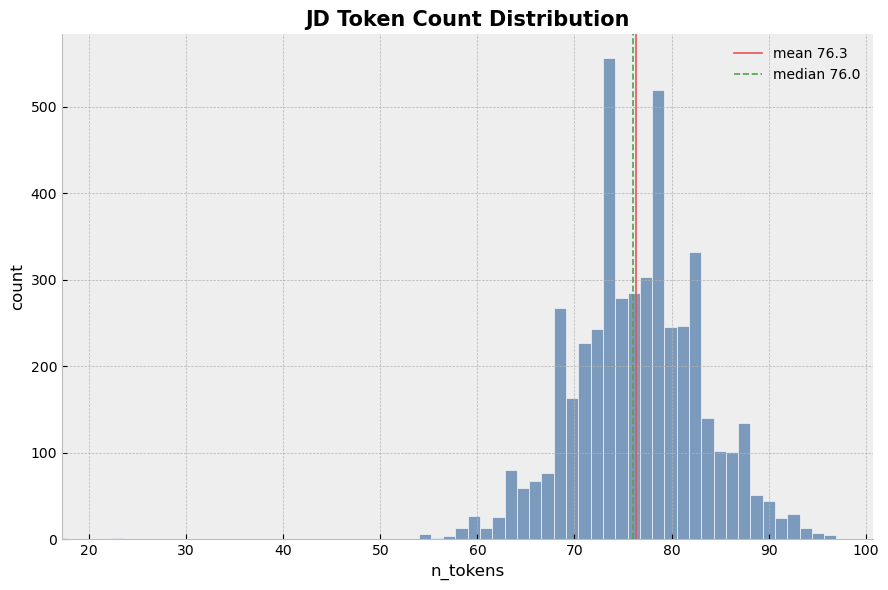

Saved: C:\Users\Keya Barua\Documents\MSC Data Science - Middlesex University\CST 4090\figures\jd_tokens_hist.png


In [98]:
# Token histogram
vals = out["n_tokens"].dropna().to_numpy()

plt.style.use("bmh")
fig, ax = plt.subplots(figsize=(9,6), dpi=100)

bins = min(60, max(20, int(np.sqrt(vals.size))))
ax.hist(vals, bins=bins, color="#4C78A8", alpha=0.70,
        edgecolor="white", linewidth=0.6, zorder=1)

mean, p50 = float(vals.mean()), float(np.median(vals))
print(f"mean={mean:.2f}, median={p50:.2f}")

# draw on top of bars/grid
ax.axvline(mean,  color="#E45756", lw=1.2, ls="-",  label=f"mean {mean:.1f}",  zorder=5)
ax.axvline(p50,   color="#54A24B", lw=1.2, ls="--", label=f"median {p50:.1f}", zorder=5)

ax.set_title("JD Token Count Distribution", fontsize=15, weight="bold")
ax.set_xlabel("n_tokens"); ax.set_ylabel("count")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.legend(frameon=False, loc="upper right")

fig_path = FIGURES_DIR / "jd_tokens_hist.png"
fig.tight_layout(); fig.savefig(fig_path, bbox_inches="tight"); plt.show()
print("Saved:", fig_path)


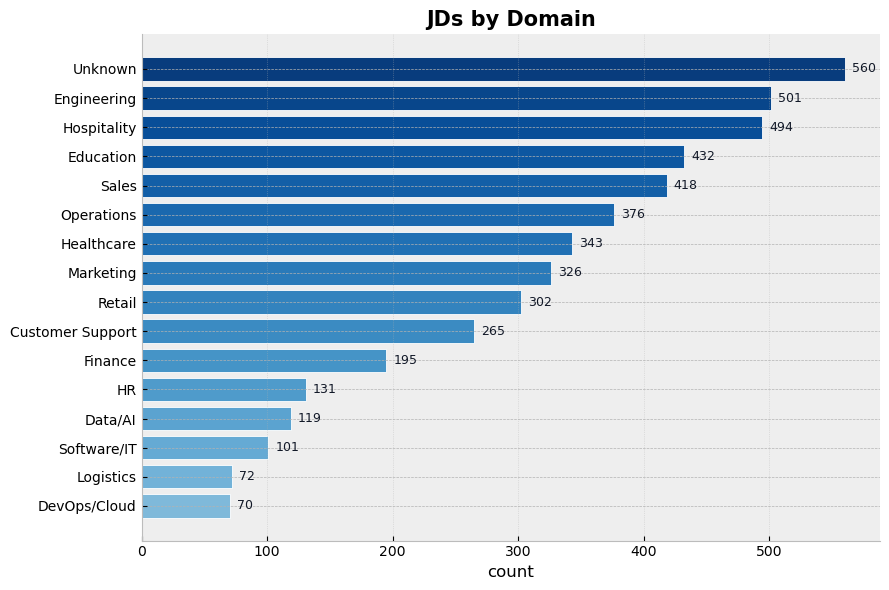

Saved: C:\Users\Keya Barua\Documents\MSC Data Science - Middlesex University\CST 4090\figures\jd_by_domain_counts.png


In [96]:
# JDs by domain bar chart
dom_counts = (
    out["domain"].fillna("").replace("", "Unknown").value_counts()
)

plt.style.use("bmh")
fig, ax = plt.subplots(figsize=(9, 6), dpi=100)

# horizontal bars, sorted for readability
dom_counts_sorted = dom_counts.sort_values(ascending=True)
y = np.arange(len(dom_counts_sorted))
cmap = plt.cm.Blues
colors = cmap(np.linspace(0.45, 0.95, len(dom_counts_sorted)))

bars = ax.barh(y, dom_counts_sorted.values, color=colors, edgecolor="white", linewidth=0.6)

# add value labels at the end of each bar
for rect, v in zip(bars, dom_counts_sorted.values):
    ax.text(rect.get_width() + max(dom_counts_sorted.values)*0.01,
            rect.get_y() + rect.get_height()/2,
            f"{v:,}", va="center", fontsize=9, color="#111827")

ax.set_yticks(y)
ax.set_yticklabels(dom_counts_sorted.index)
ax.set_xlabel("count")
ax.set_title("JDs by Domain", fontsize=15, weight="bold")
ax.grid(axis="x", linestyle=":", alpha=0.6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig2_path = FIGURES_DIR / "jd_by_domain_counts.png"
fig.tight_layout()
fig.savefig(fig2_path, bbox_inches="tight")
plt.show()
print("Saved:", fig2_path)

#### Quality report & acceptance checks

We save reports/jd_quality.json with:

- total JDs fetched

- rows after cleaning & filters

- number of duplicates removed

- avg / median tokens

- domain counts

In [94]:
# Quality JSON
buckets = pd.cut(out["n_tokens"], bins=[0,50,100,200,400,800,1600,1e9],
                 right=False).value_counts().sort_index() if "n_tokens" in out.columns else {}
quality = {
    "n_rows": int(len(out)),
    "avg_chars": float(out["n_chars"].mean() if "n_chars" in out.columns and len(out) else float("nan")),
    "avg_tokens": float(out["n_tokens"].mean() if "n_tokens" in out.columns and len(out) else float("nan")),
    "token_buckets": {str(k): int(v) for k, v in (buckets.items() if hasattr(buckets, "items") else[])},
    "online_fetch": bool(ONLINE),
    "country": COUNTRY,
}
# Include roles/locations or plan domains in the report
if plan is not None and len(plan):
    quality["plan_domains"] = sorted(set(plan["domain"].astype(str)))
    quality["plan_queries"] = sorted(set(plan["what"].astype(str)))[:20]
    quality["plan_locations"] = sorted(set(sum([str(x).split("|") for x in plan["locations"]], [])))
else:
    quality["roles"] = ROLES
    quality["locations"] = LOCATIONS

with open(QUALITY_JSON, "w") as f:
    json.dump(quality, f, indent=2)

print("[Done] Cleaned JDs", CLEAN_CSV)
print("[Done] Quality report", QUALITY_JSON)

[Done] Cleaned JDs C:\Users\Keya Barua\Documents\MSC Data Science - Middlesex University\CST 4090\data\processed\jd_clean.csv
[Done] Quality report C:\Users\Keya Barua\Documents\MSC Data Science - Middlesex University\CST 4090\reports\jd_quality.json


In [64]:
def keep_count(tokens=[20,50, 80,120,150,200], chars=[100,200, 300,400,500,800]):
    base = out.assign(n_tokens=out["jd_text"].astype(str).str.split().map(len),
                      n_chars=out["jd_text"].str.len())
    print("Total rows:", len(base))
    for t,c in zip(tokens, chars):
        n = ((base["n_tokens"]>=t)&(base["n_chars"]>=c)).sum()
        print(f"toks≥{t}, chars≥{c}: {n} rows ({n/len(base):.1%})")
keep_count()

Total rows: 4705
toks≥20, chars≥100: 4705 rows (100.0%)
toks≥50, chars≥200: 4697 rows (99.8%)
toks≥80, chars≥300: 1476 rows (31.4%)
toks≥120, chars≥400: 0 rows (0.0%)
toks≥150, chars≥500: 0 rows (0.0%)
toks≥200, chars≥800: 0 rows (0.0%)
